# Etapa 4: Modelagem com Regressão Linear

Objetivos de Aprendizagem 5 e 6: ajustar uma **regressão linear múltipla** com scikit-learn, avaliá-la com R², RMSE e MAE e interpretar os coeficientes.

Roteiro do PDF:

1. Variáveis preditoras sugeridas: `area_m2`, `quartos`, `banheiros`, `vagas`.
2. Adicionar `bairro` via **One-Hot Encoding** (aqui, `tipo` também).
3. Comparar com **Ridge/Lasso**.
4. Testar transformação **logarítmica** em `preco`.
5. Verificar **multicolinearidade** (VIF).

## Imports

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LassoCV, LinearRegression, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

df = pd.read_csv("imoveis_limpos.csv", dtype={"id": str})   # id como texto: é código, não número
print(f"Limpos carregados: {df.shape[0]} linhas x {df.shape[1]} colunas")

Limpos carregados: 245 linhas x 15 colunas


## Métricas

Todas são calculadas no conjunto de **teste** (imóveis que o modelo não viu):

- **R²:** fração da variação do preço explicada pelo modelo (1 = perfeito; negativo = pior que chutar a média).
- **RMSE:** erro típico em R\$, punindo mais os erros grandes.
- **MAE:** erro médio absoluto em R\$ ("em média, erra X reais").

In [ ]:
resultados = []   # um dicionário por modelo, para a tabela comparativa


def avaliar(nome, y_real, y_previsto):                      # a função `avaliar` calcula R², RMSE e MAE, imprime e guarda em `resultados`
    """Calcula R², RMSE e MAE, imprime e guarda em `resultados`."""
    r2 = r2_score(y_real, y_previsto)
    rmse = np.sqrt(mean_squared_error(y_real, y_previsto))
    mae = mean_absolute_error(y_real, y_previsto)
    print(f"{nome:<22} R²={r2:.3f}  RMSE=R$ {rmse:,.0f}  MAE=R$ {mae:,.0f}")
    resultados.append({"modelo": nome, "R2": r2, "RMSE": rmse, "MAE": mae})

## (a) RLM com as preditoras sugeridas

$$\widehat{preco} = \beta_0 + \beta_1\,area\_m2 + \beta_2\,quartos + \beta_3\,banheiros + \beta_4\,vagas$$

Divisão **80% treino / 20% teste**. O `random_state=42` fixa o sorteio, então todos os modelos são testados nos mesmos imóveis.

In [13]:
features = ["area_m2", "quartos", "banheiros", "vagas"]
y = df["preco"]

X = df[features]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Treino: {len(X_train)} imóveis | Teste: {len(X_test)} imóveis\n")

rlm = LinearRegression().fit(X_train, y_train)   # mínimos quadrados (MQO)
avaliar("RLM numéricas", y_test, rlm.predict(X_test))

print("\n--- Coeficientes (R$ por +1 unidade) ---")
print(pd.Series(rlm.coef_, index=features).round(0))   # mantendo o resto constante
print(f"Intercepto: {rlm.intercept_:,.0f}")

Treino: 196 imóveis | Teste: 49 imóveis

RLM numéricas          R²=0.816  RMSE=R$ 475,255  MAE=R$ 319,965

--- Coeficientes (R$ por +1 unidade) ---
area_m2        -153.0
quartos      308492.0
banheiros    223597.0
vagas        253947.0
dtype: float64
Intercepto: -155,206


## (b) + `bairro` e `tipo` (One-Hot Encoding)

A regressão só entende números, então cada bairro e cada tipo vira uma coluna 0/1. O `drop_first=True` remove uma categoria de cada variável, que vira a **referência** (**Asa Norte** e **apartamento**). Sem isso, as colunas somariam sempre 1 e repetiriam o intercepto (armadilha das dummies).

Leitura: o coeficiente de `bairro_Noroeste` é quanto um imóvel **igual** custa a mais ou a menos no Noroeste do que na Asa Norte.

In [14]:
X2 = pd.get_dummies(df[features + ["bairro", "tipo"]], columns=["bairro", "tipo"], drop_first=True, dtype=int)
X2_train, X2_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=42)   # mesmo sorteio do (a)

print(f"Colunas após o One-Hot ({X2.shape[1]}): {list(X2.columns)}\n")

rlm2 = LinearRegression().fit(X2_train, y_train)
avaliar("RLM + bairro + tipo", y_test, rlm2.predict(X2_test))

print("\n--- Coeficientes (R$, referência: Asa Norte / apartamento) ---")
print(pd.Series(rlm2.coef_, index=X2.columns).round(0))

Colunas após o One-Hot (10): ['area_m2', 'quartos', 'banheiros', 'vagas', 'bairro_Asa Sul', 'bairro_Lago Norte', 'bairro_Lago Sul', 'bairro_Noroeste', 'bairro_Sudoeste', 'tipo_casa']

RLM + bairro + tipo    R²=0.911  RMSE=R$ 329,559  MAE=R$ 238,292

--- Coeficientes (R$, referência: Asa Norte / apartamento) ---
area_m2                 5545.0
quartos               114297.0
banheiros             210137.0
vagas                 286912.0
bairro_Asa Sul         28187.0
bairro_Lago Norte    -165508.0
bairro_Lago Sul       437342.0
bairro_Noroeste        49427.0
bairro_Sudoeste       197949.0
tipo_casa           -2153024.0
dtype: float64


## (c) Comparando com Ridge e Lasso

Regressões com um "freio" nos coeficientes, para reduzir *overfitting*:

- **Ridge (L2):** encolhe todos os coeficientes, sem zerar nenhum.
- **Lasso (L1):** pode **zerar** coeficientes, o que funciona como seleção de variáveis.

O α (força do freio) é escolhido por validação cruzada. Padronizar (`StandardScaler`) é obrigatório para a penalidade ser justa entre escalas diferentes (m² × nº de quartos).

In [15]:
# pipeline: o scaler aprende média/desvio só no treino (sem vazar informação do teste)
ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 4, 50))).fit(X2_train, y_train)
avaliar("Ridge", y_test, ridge.predict(X2_test))

lasso = make_pipeline(StandardScaler(), LassoCV(cv=5, max_iter=50_000, random_state=42)).fit(X2_train, y_train)
avaliar("Lasso", y_test, lasso.predict(X2_test))
print(f"\nalpha Ridge: {ridge[-1].alpha_:.2f} | alpha Lasso: {lasso[-1].alpha_:,.0f}")   # [-1] = último passo do pipeline
zerados = X2.columns[lasso[-1].coef_ == 0]
print(f"Lasso zerou {len(zerados)} de {X2.shape[1]} coeficientes: {list(zerados)}")

Ridge                  R²=0.910  RMSE=R$ 332,196  MAE=R$ 241,248
Lasso                  R²=0.905  RMSE=R$ 341,051  MAE=R$ 242,873

alpha Ridge: 3.73 | alpha Lasso: 14,198
Lasso zerou 1 de 10 coeficientes: ['bairro_Asa Sul']


## (d) Transformação logarítmica em `preco`

O modelo passa a prever $\ln(preco)$, o que corrige a cauda longa e o "funil" dos resíduos. Antes de medir o erro, o valor volta para reais com `np.exp`.

Também testamos o log na área (**log-log**): o preço cresce de forma **proporcional** à área, e o coeficiente vira uma elasticidade (+1% de área → +β% no preço).

In [16]:
rlm_log = LinearRegression().fit(X2_train, np.log(y_train))
avaliar("RLM log(preco)", y_test, np.exp(rlm_log.predict(X2_test)))   # exp: volta para R$ antes das métricas

X3_train = X2_train.assign(area_m2=np.log(X2_train["area_m2"]))
X3_test = X2_test.assign(area_m2=np.log(X2_test["area_m2"]))
rlm_loglog = LinearRegression().fit(X3_train, np.log(y_train))
avaliar("RLM log-log", y_test, np.exp(rlm_loglog.predict(X3_test)))

print(f"\nElasticidade preço-área (log-log): {rlm_loglog.coef_[0]:.3f}")

RLM log(preco)         R²=0.835  RMSE=R$ 449,362  MAE=R$ 307,565
RLM log-log            R²=0.886  RMSE=R$ 373,848  MAE=R$ 252,021

Elasticidade preço-área (log-log): 0.804


## Comparação dos modelos

Esta tabela é a "especificação do modelo e métricas" do relatório (Etapa 5, item 4).

In [17]:
comparacao = pd.DataFrame(resultados).set_index("modelo")
print(f"Melhor R²: {comparacao['R2'].idxmax()} | menor MAE: {comparacao['MAE'].idxmin()}\n")
comparacao.round(3)

Melhor R²: RLM + bairro + tipo | menor MAE: RLM + bairro + tipo



,R2,RMSE,MAE
modelo,,,
RLM numéricas,0.816,475255.110,319964.521
RLM + bairro + tipo,0.911,329558.945,238291.775
Ridge,0.910,332196.394,241248.148
Lasso,0.905,341051.134,242872.856
RLM log(preco),0.835,449362.453,307564.641
RLM log-log,0.886,373848.218,252021.042


## Multicolinearidade (VIF)

$VIF_j = \dfrac{1}{1 - R_j^2}$, onde $R_j^2$ vem da regressão da variável $j$ contra as outras preditoras. Leitura: 1 a 5 é aceitável, 5 a 10 é preocupante e acima de 10 é grave. Com multicolinearidade alta, as previsões continuam boas, mas os coeficientes ficam instáveis e difíceis de interpretar.

In [18]:
Xv = add_constant(df[features])   # o VIF precisa da coluna de 1s (intercepto)
vif = pd.DataFrame({
    "variavel": Xv.columns,
    "VIF": [variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])],
})
print("--- VIF (1-5 ok | 5-10 preocupante | >10 grave) ---")
print(vif[vif["variavel"] != "const"].round(2))

--- VIF (1-5 ok | 5-10 preocupante | >10 grave) ---
    variavel   VIF
1    area_m2  3.54
2    quartos  4.11
3  banheiros  4.83
4      vagas  3.03


## Resíduos

Resíduo = real − previsto. O ideal é uma nuvem sem padrão em volta do zero. Um **funil** (erros maiores nos imóveis caros) indica variância não constante e reforça o uso do log.

Como cada linha guarda `id` e `link`, dá para abrir no site os anúncios em que o modelo mais errou e entender o motivo (andar, estado de conservação, vista...: variáveis que o card não traz).

Resíduo médio: R$ 15,754 (ideal ≈ 0)
Previsões negativas: 0



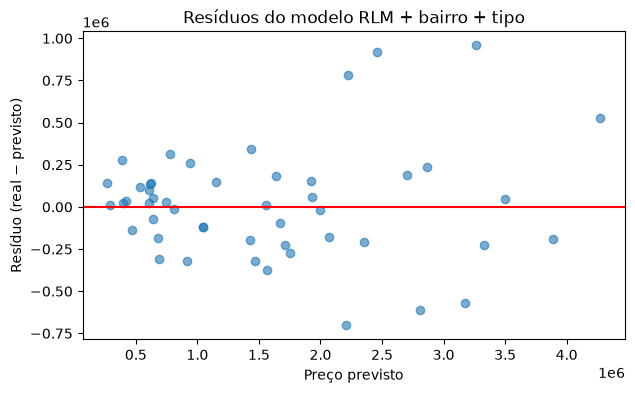

--- 5 maiores erros do modelo (em módulo) ---
        id    bairro        tipo     preco  previsto   residuo                                                                                                                                      link
2864021084  Sudoeste apartamento 4221037.0 3263751.0  957286.0 https://www.vivareal.com.br/imovel/apartamento-4-quartos-setor-sudoeste-bairros-brasilia-com-garagem-168m2-venda-RS4221037-id-2864021084/
2901046710  Sudoeste apartamento 3375000.0 2458315.0  916685.0 https://www.vivareal.com.br/imovel/apartamento-3-quartos-setor-sudoeste-bairros-brasilia-com-garagem-133m2-venda-RS3375000-id-2901046710/
2869573987  Lago Sul        casa 3000000.0 2220049.0  779951.0           https://www.vivareal.com.br/imovel/sobrado-5-quartos-lago-sul-bairros-brasilia-com-garagem-356m2-venda-RS3000000-id-2869573987/
2865572161 Asa Norte apartamento 1500000.0 2203344.0 -703344.0      https://www.vivareal.com.br/imovel/apartamento-4-quartos-asa-norte-bairros-brasili

In [19]:
previsto = rlm2.predict(X2_test)
residuos = y_test - previsto
print(f"Resíduo médio: R$ {residuos.mean():,.0f} (ideal ≈ 0)")
print(f"Previsões negativas: {(previsto < 0).sum()}\n")

plt.figure(figsize=(7, 4))
plt.scatter(previsto, residuos, alpha=0.6)
plt.axhline(0, color="red")   # linha do erro zero
plt.xlabel("Preço previsto")
plt.ylabel("Resíduo (real − previsto)")
plt.title("Resíduos do modelo RLM + bairro + tipo")
plt.savefig("figs/residuos.png", dpi=150)
plt.show()

erros = df.loc[y_test.index, ["id", "bairro", "tipo", "preco"]].assign(previsto=previsto.round(0), residuo=residuos.round(0),
                                                                     link=df.loc[y_test.index, "link"])
print("--- 5 maiores erros do modelo (em módulo) ---")
print(erros.reindex(erros["residuo"].abs().sort_values(ascending=False).index).head(5).to_string(index=False))

## Interpretação dos coeficientes (Etapa 5, item 5)

- **Modelo linear:** "mantidas as demais variáveis constantes, cada m² adicional eleva o preço em R\$ X".
- **Modelo log:** efeito de +1 unidade $= (e^{\beta} - 1)\times 100\%$.

Associação não é causa: "imóveis com mais banheiros custam mais" não significa que construir um banheiro aumenta o preço nessa proporção.

In [ ]:
coefs = pd.Series(rlm2.coef_, index=X2.columns)
print("--- Modelo linear (R$) ---")
print(f"Cada m² adicional eleva o preço em R$ {coefs['area_m2']:,.0f}")
print(f"Cada vaga adicional eleva o preço em R$ {coefs['vagas']:,.0f}")
print(f"Cada banheiro adicional eleva o preço em R$ {coefs['banheiros']:,.0f}\n")

coefs_log = pd.Series(rlm_log.coef_, index=X2.columns)
print("--- Modelo log(preco) (%) ---")
print((100 * (np.exp(coefs_log) - 1)).round(1).rename("% no preço por +1 unidade"))

--- Modelo linear (R$) ---
Cada m² adicional eleva o preço em R$ 5,545
Cada vaga adicional eleva o preço em R$ 286,912
Cada banheiro adicional eleva o preço em R$ 210,137

--- Modelo log(preco) (%) ---
area_m2               0.3
quartos              27.7
banheiros            11.3
vagas                12.2
bairro_Asa Sul        3.0
bairro_Lago Norte   -10.6
bairro_Lago Sul       4.6
bairro_Noroeste      12.6
bairro_Sudoeste      -2.1
tipo_casa           -68.4
Name: % no preço por +1 unidade, dtype: float64


## Conclusões (coleta de 30/09/2026, 245 imóveis)

- Só com as numéricas o modelo explica ~82% do preço; com `bairro` e `tipo`, **~91%** (MAE ≈ R\$ 238 mil), o melhor da comparação.
- No modelo só com numéricas, o coeficiente da área sai **negativo** (−R\$ 153/m²): misturar casas (muita área, m² barato) com apartamentos confunde a reta. Com `tipo` no modelo, cada m² passa a valer +R\$ 5,5 mil.
- Ridge/Lasso quase não mudam nada: com só 10 colunas, não há *overfitting* para frear. O Lasso zerou `bairro_Asa Sul`, ou seja, a Asa Sul custa o mesmo que a Asa Norte (a referência).
- `log(preco)` sozinho piorou (R² 0,84); o **log-log** ficou em R² 0,89, com elasticidade 0,80 (+1% de área → +0,8% no preço).
- VIF de todas as preditoras abaixo de 5 (banheiros ≈ 4,8, no limite): banheiros, quartos e área andam juntos.
- Limitações (Etapa 5, item 6): **amostra pequena** (245 imóveis; o Lago Sul caiu de 49 para 17 na remoção de outliers), **viés de anúncios** (preço anunciado ≠ preço de venda; anúncios em destaque aparecem mais), **seleção geográfica** (só Plano Piloto e Lagos, primeiras páginas da busca), dados de um único dia e variáveis ausentes (andar, idade, estado do imóvel). Coletar também no ZAP não aumentaria a amostra: os anúncios e IDs são os mesmos do VivaReal.

### Onde está cada item do relatório (Etapa 5)

| Item | Onde |
|---|---|
| 1. Fonte de dados e método de coleta | `01_coleta` (Recon 0 a 4, Bypass, Coleta) |
| 2. Estatísticas descritivas | `02`: Estatística descritiva |
| 3. Gráficos da EDA | pasta `figs/` |
| 4. Especificação do modelo e métricas | `03`: (a) a (d) + Comparação |
| 5. Interpretação dos coeficientes | `03`: Interpretação |
| 6. Limitações | acima |
| 7. Considerações éticas | `01`: `robots.txt`, pausas com jitter, sem dados pessoais do anunciante (LGPD), sem CAPTCHA/login contornado, uso acadêmico |